In [1]:
import os
import timm
import torch
import numpy as np

import utils.data as data_utils
from utils.predict import PredictPlants

random_seed = 8

/home/takayuki/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Model

In [2]:
timm_model_name = "convnextv2_tiny.fcmae_ft_in22k_in1k"

best_model_path = "/home/takayuki/Desktop/summer2025/plants/training/models/best_model_06-21_12-52--22_tiny28M_stratified_convnextv2_tiny.fcmae_ft_in22k_in1k.pth"
if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Model file not found: {best_model_path}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    torch.cuda.manual_seed(random_seed)
    print("GPU: ", torch.cuda.get_device_name(0))
    
model = timm.create_model(timm_model_name, pretrained=False, num_classes=21)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

print(f"Model loaded from {best_model_path}")

Using device: cuda
GPU:  NVIDIA RTX A500 Laptop GPU
Model loaded from /home/takayuki/Desktop/summer2025/plants/training/models/best_model_06-21_12-52--22_tiny28M_stratified_convnextv2_tiny.fcmae_ft_in22k_in1k.pth


## Predictor

In [3]:
predictor = PredictPlants(timm_model_name, best_model_path, 21)

## Hands Dataset

Using the entire dataset as the test set. No train/val split.
Inspecting directory: /home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/hand_squared
Found 9 classes locally: ['Hydrocharis morsus-ranae', 'Myriophyllum spicatum', 'Nitellopsis obtusa', 'Nuphar variegata', 'Potamogeton crispus', 'Potamogeton gramineus', 'Potamogeton illinoensis', 'Potamogeton richardsonii', 'Ranunculus aquatilis']
Remapped 19 images to use canonical indices.
Total dataset size 	: 19
Calculated train size 	: 0
Calculated val size 	: 0
Calculated test size 	: 19

Test DataLoader created with 19 images from /home/takayuki/Desktop/summer2025/plants/data/AquaticPlantLabData/hand_squared.
Classnames 
True label: tensor([5])


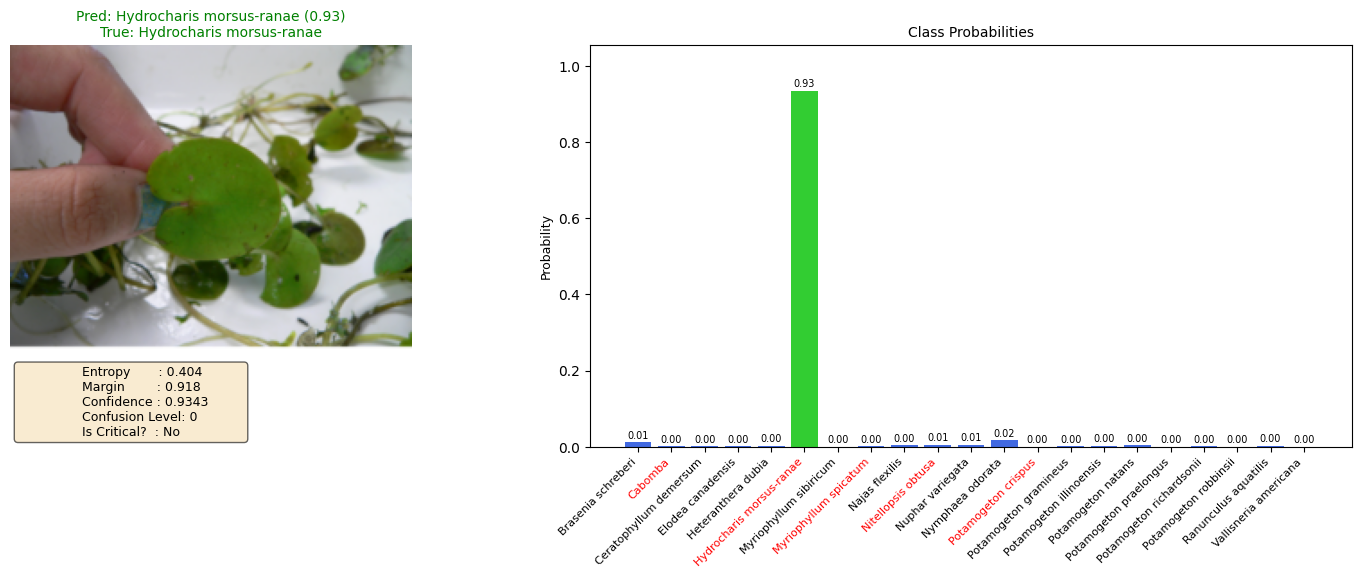


Prediction Summary:
+-----------------+--------------------------+--------------------------+--------------+
| Metric          | Value                    | Top-k Prediction         |   Confidence |
+=================+==========================+==========================+==============+
| Predicted Class | Hydrocharis morsus-ranae | Hydrocharis morsus-ranae |       0.9343 |
+-----------------+--------------------------+--------------------------+--------------+
| Confidence      | 0.9343                   | Nymphaea odorata         |       0.0168 |
+-----------------+--------------------------+--------------------------+--------------+
| Entropy         | 0.4044                   | Brasenia schreberi       |       0.0115 |
+-----------------+--------------------------+--------------------------+--------------+
| Margin          | 0.9175                   | Nuphar variegata         |       0.0059 |
+-----------------+--------------------------+--------------------------+--------------+


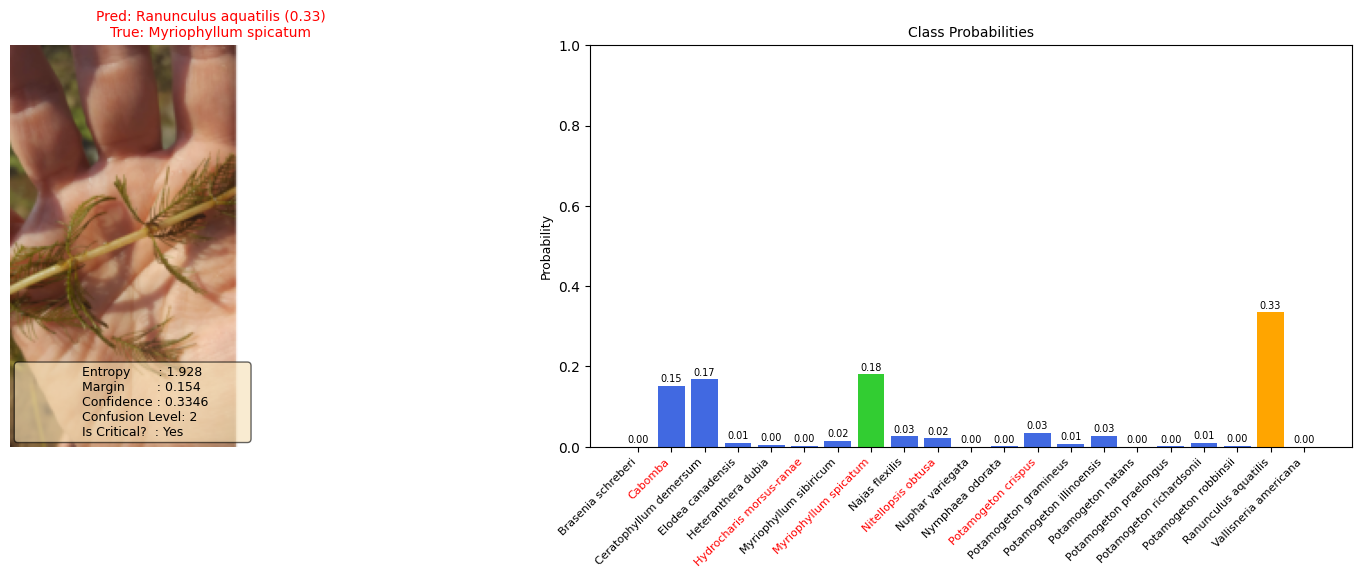


Prediction Summary:
+-----------------+----------------------+-------------------------+--------------+
| Metric          | Value                | Top-k Prediction        |   Confidence |
+=================+======================+=========================+==============+
| Predicted Class | Ranunculus aquatilis | Ranunculus aquatilis    |       0.3346 |
+-----------------+----------------------+-------------------------+--------------+
| Confidence      | 0.3346               | Myriophyllum spicatum   |       0.1805 |
+-----------------+----------------------+-------------------------+--------------+
| Entropy         | 1.9276               | Ceratophyllum demersum  |       0.1679 |
+-----------------+----------------------+-------------------------+--------------+
| Margin          | 0.1541               | Cabomba                 |       0.1521 |
+-----------------+----------------------+-------------------------+--------------+
| Is Correct?     | False                | Potamogeton 

/home/takayuki/Desktop/summer2025/plants/plant_classification/utils/predict.py:455: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_names, y=scores, palette="viridis")


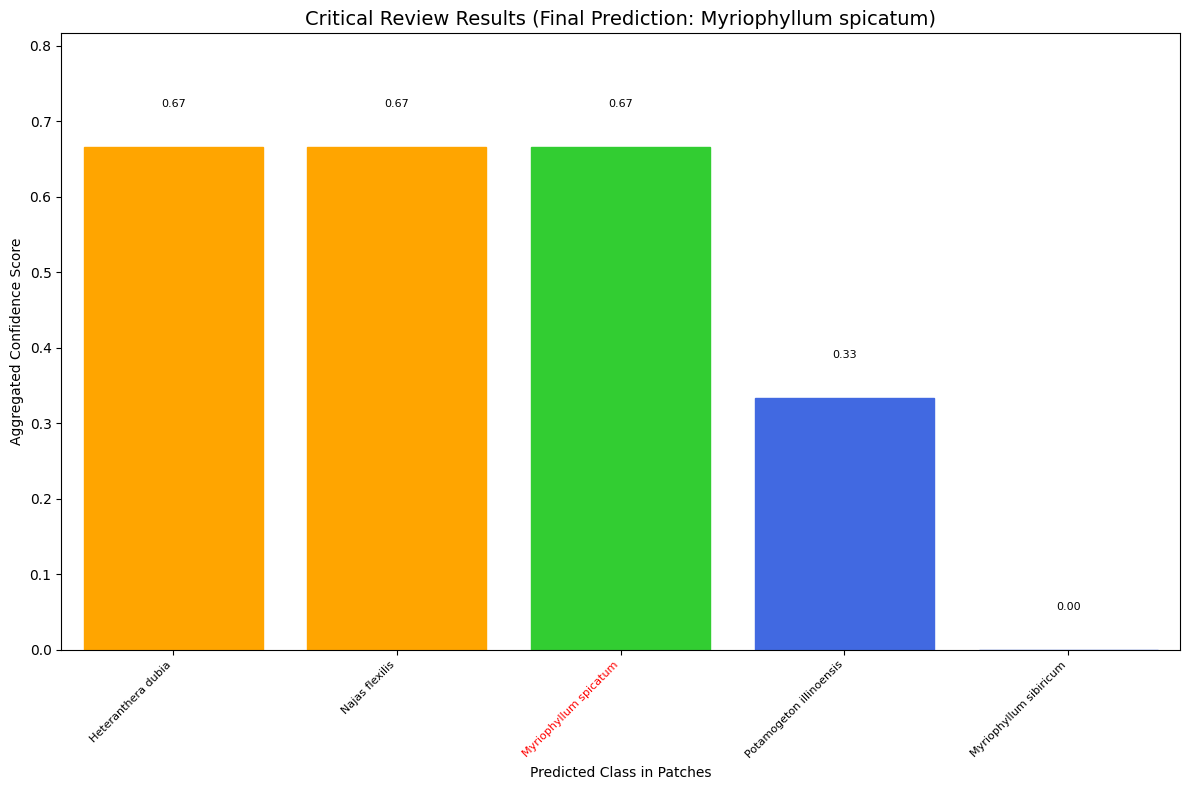


Critical Review Summary:
+------------------------+-----------------------+
| Metric                 | Value                 |
+========================+=======================+
| Final Prediction Class | Myriophyllum spicatum |
+------------------------+-----------------------+
| Final Prediction Index | 7                     |
+------------------------+-----------------------+
| Number of Patches      | 12                    |
+------------------------+-----------------------+
| Is Tie?                | True                  |
+------------------------+-----------------------+
| True Label Class       | Myriophyllum spicatum |
+------------------------+-----------------------+
| True Label Index       | 7                     |
+------------------------+-----------------------+
| Is Correct?            | True                  |
+------------------------+-----------------------+
Final Prediction after Critical Review: Myriophyllum spicatum


In [4]:
hand_dataloader = data_utils.get_test_dataloader()
results = predictor.predict_on_dataloader(hand_dataloader, num_preds=2, k = 8)

## Patch and Predict